# Name : Priyanshu Kumar Singh
# OASIS INFOBYTE DATA SCIENCE INTERNSHIP
# TASK 3 : Car Price Prediction Using Machine Learning

### Project Overview:

This project focuses on building an end-to-end machine learning pipeline to predict the resale prices of used cars using the CarDekho dataset. The goal is to perform thorough data cleaning, exploratory data analysis (EDA), and feature engineering to evaluate and compare predictive models for accurate valuation.

## Key Highlights:

Dataset: CarDekho Used Car Data (CAR DETAILS FROM CAR DEKHO.csv)

Target Variable: selling_price

Key Features: Vehicle age (car_age), mileage driven (km_driven), transmission type, fuel type, owner history, and extracted brand names.

In [43]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

In [44]:
#Loading the dataset into a pandas DataFrame :

In [45]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
print(df)

                                     name  year  selling_price  km_driven  \
0                           Maruti 800 AC  2007          60000      70000   
1                Maruti Wagon R LXI Minor  2007         135000      50000   
2                    Hyundai Verna 1.6 SX  2012         600000     100000   
3                  Datsun RediGO T Option  2017         250000      46000   
4                   Honda Amaze VX i-DTEC  2014         450000     141000   
...                                   ...   ...            ...        ...   
4335  Hyundai i20 Magna 1.4 CRDi (Diesel)  2014         409999      80000   
4336           Hyundai i20 Magna 1.4 CRDi  2014         409999      80000   
4337                  Maruti 800 AC BSIII  2009         110000      83000   
4338     Hyundai Creta 1.6 CRDi SX Option  2016         865000      90000   
4339                     Renault KWID RXT  2016         225000      40000   

        fuel seller_type transmission         owner  
0     Petrol  Individ

In [46]:
#here, we find that the dataset has 4340 rows and 8 columns

In [47]:
#now, we will inspect the dataset

In [48]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB
None
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  sel

In [49]:
#here, we get the info of the dataset, using df.info()

# Data Cleaning

Handling of Null Values, by identifying missing values across all columns and handle them appropriately

In [50]:
# Check missing counts
print(df.isnull().sum())

# Drop rows containing missing values or impute numerical/categorical columns
df = df.dropna()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [51]:
#by using isnull(), we get to see whether any missing values are there in the dataset

Removing Duplicates:

In [52]:
df = df.drop_duplicates().reset_index(drop=True)

In [53]:
# the removal of the duplicates within the dataset is done in this step

Let's view the columns tolist:

In [54]:
print(df.columns.tolist())

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


Addressing the Inconsistent Categorical Values by standardizing text across all string columns to resolve formatting issues like "Petrol" vs. "petrol":

In [55]:
# using Categorical Columns

In [56]:
categorical_cols = df.select_dtypes(include=['object','str']).columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    print(f"Unique in {col}: {df[col].unique()}")

Unique in name: <ArrowStringArray>
[                               'maruti 800 ac',
                     'maruti wagon r lxi minor',
                         'hyundai verna 1.6 sx',
                       'datsun redigo t option',
                        'honda amaze vx i-dtec',
                         'maruti alto lx bsiii',
                    'hyundai xcent 1.2 kappa s',
                     'tata indigo grand petrol',
                     'hyundai creta 1.6 vtvt s',
                     'maruti celerio green vxi',
 ...
                    'honda amaze s petrol bsiv',
         'hyundai santro xing xs erlx euro iii',
                            'hyundai santro at',
           'ford endeavour 2.2 titanium at 4x2',
                   'chevrolet spark 1.0 lt bs3',
                             'maruti swift ldi',
                                 'tata nano xm',
                 'mahindra verito 1.5 d6 bsiii',
 'toyota innova 2.5 vx (diesel) 8 seater bs iv',
                   'hyundai i

In [57]:
#here, upon performing standardization of the keywords, like Petrol vs petrol, we may be able to resolve any conflicting errors

# Calculating Car Age from Year Column:

In [58]:
from datetime import datetime

# Safely check if 'year' exists, or if 'car_age' was already created
if 'year' in df.columns:
    current_year = datetime.now().year
    df['car_age'] = current_year - pd.to_numeric(df['year'], errors='coerce')
    df.drop(columns=['year'], inplace=True)
    print("car_age created successfully!")
elif 'car_age' in df.columns:
    print("car_age column already exists.")
else:
    print("Neither 'year' nor 'car_age' found. Reload the dataset if needed.")

car_age created successfully!


Let's see the values for the respective car ages

In [59]:
df[['car_age']].head()

,car_age
0,19
1,19
2,14
3,9
4,12


In [60]:
# here, visibly the car ages are successfully created!

# Extraction of brand name:

In [61]:
if 'name' in df.columns:
    df['brand'] = df['name'].apply(lambda x: str(x).split()[0])
    df.drop(columns=['name'], inplace=True)
    print("Brand column created successfully!")
elif 'brand' in df.columns:
    print("Brand column already exists.")

Brand column created successfully!


Inspecting the brand names of the cars in the dataset:

In [62]:
df[['brand']]

,brand
0,maruti
1,maruti
2,hyundai
3,datsun
4,honda
...,...
3572,hyundai
3573,hyundai
3574,maruti
3575,hyundai


In [63]:
# upon checking for the car brand names, we can visibly witness the names display on our screen!

# Exploratory Data Analysis (EDA)
Distribution of Selling Prices:

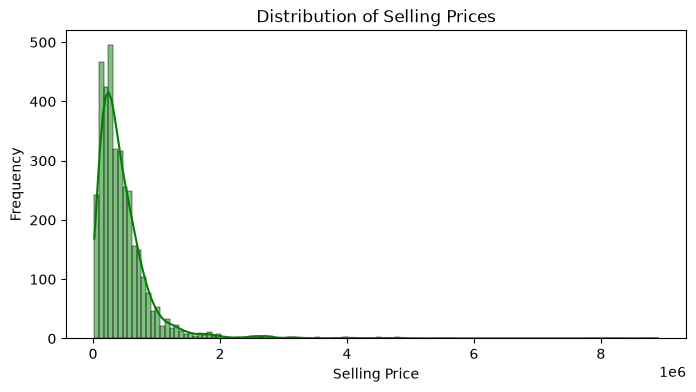

In [64]:
plt.figure(figsize=(8, 4))
# Changed 'Selling_Price' to 'selling_price'
sns.histplot(df['selling_price'], kde=True, color='green') 
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

In [65]:
# the plotting of the EDA:distribution of selling prices is performed

Price vs. Fuel Type Box Plots:

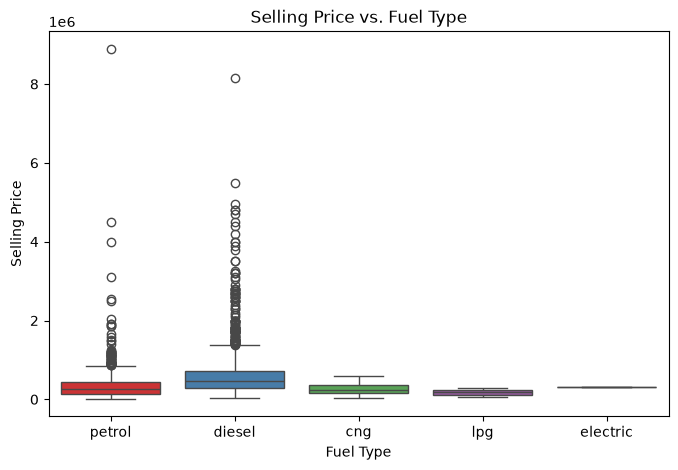

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuel', y='selling_price', data=df, hue = 'fuel', palette='Set1', legend = False)
plt.title('Selling Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

In [67]:
#the above plot shows the representation of the price vs fuel type box plot

Price vs Car age scatter plot

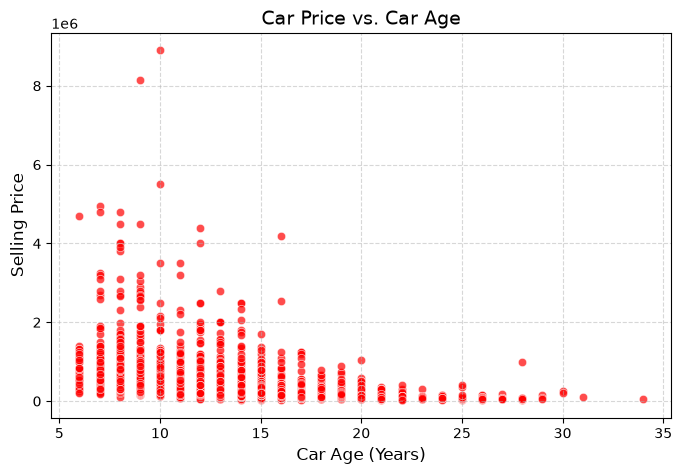

In [68]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='car_age', y=df.columns[df.columns.str.lower().str.contains('price')][0], alpha=0.7, color='red')
plt.title('Car Price vs. Car Age', fontsize=14)
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [69]:
#upon plotting the selling price vs car age scatter plot, the above representation is obtained

# Key Observations from EDA Plots
In the plot of Distribution of Selling Prices, the distribution is highly right-skewed, showing that the majority of vehicles are clustered at lower price points.

The Selling Price vs. Fuel Type plot shows that the Diesel vehicles generally gives higher median selling prices and wider price dispersion compared to Petrol, CNG, LPG, and Electric vehicles.

In the Car Price vs. Car Age plot, there is a clear inverse relationship where selling prices decrease rapidly as vehicle age increases.

# Correlation Heatmap and One-Hot Encoding

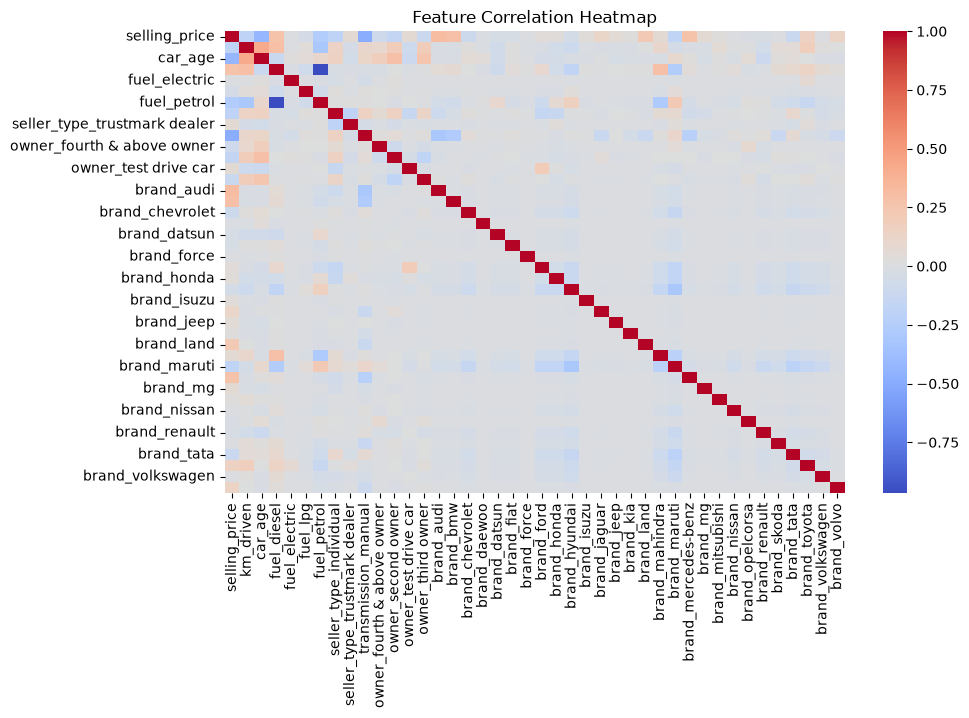

In [70]:
# Conversion of categorical features into dummy/indicator variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Generate Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [71]:
#here, by using sns and matplotlib.pyplot, we get to see the the correlation heatmap.

# Training/Testing Split and Model Training

In [72]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Separate features and target
X = df_encoded.drop(columns=['selling_price'])
y = pd.to_numeric(df_encoded['selling_price'], errors='coerce')

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# here, the splitting into 80% train and 20% test is done

# Training and Evaluating Linear Regression

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("--- Linear Regression Results ---")
print(f"MAE:  {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²:   {lr_r2:.4f}")

--- Linear Regression Results ---
MAE:  185413.76
RMSE: 380273.35
R²:   0.5511


Here, upon the training of Linear Regression model on the dataset, we get the following outputs of MAR, RMSE, and R^2:

MAE:  185413.76

RMSE: 380273.35

R²:   0.5511

Now, let's train another regression model - Random Forest Regressor, based on the dataset

In [75]:
# Training and Evaluating Random Forest:

# Training and Evaluating Random Forest:

In [76]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("--- Random Forest Regressor Results ---")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.4f}")

--- Random Forest Regressor Results ---
MAE:  158918.38
RMSE: 365567.41
R²:   0.5851


Here, upon the training of Random Forest Regressor on the dataset, we get the following outputs of MAR, RMSE, and R^2:

MAE:  158918.38

RMSE: 365567.41

R²:   0.5851

# Plotting both the models' training (Linear Regression, and Random Forest)

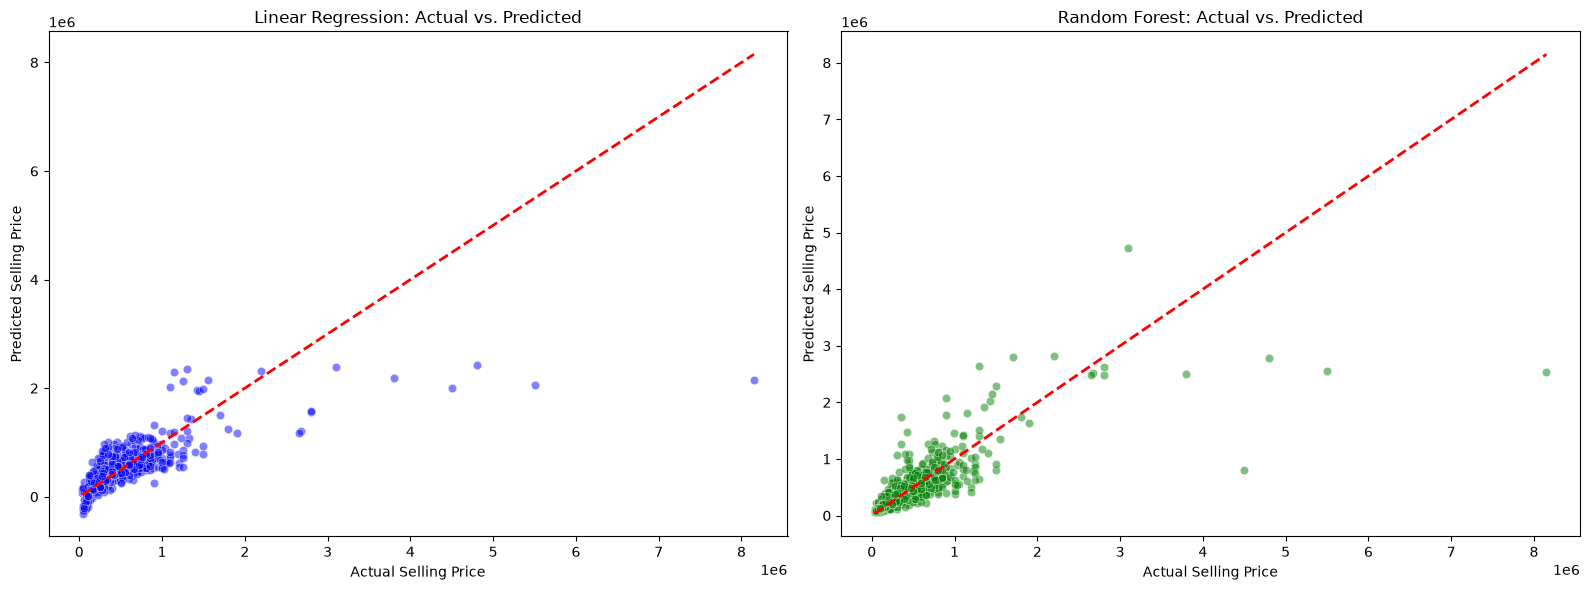

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create side-by-side plots for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Linear Regression Plot
sns.scatterplot(x=y_test, y=lr_preds, ax=axes[0], alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Actual vs. Predicted')
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')

# 2. Random Forest Regressor Plot
sns.scatterplot(x=y_test, y=rf_preds, ax=axes[1], alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Actual vs. Predicted')
axes[1].set_xlabel('Actual Selling Price')
axes[1].set_ylabel('Predicted Selling Price')

plt.tight_layout()
plt.show()

In [78]:
#the above plots show the training of the Linear regression model and random forest model onto the dataset

# Top 10 feature importances plot

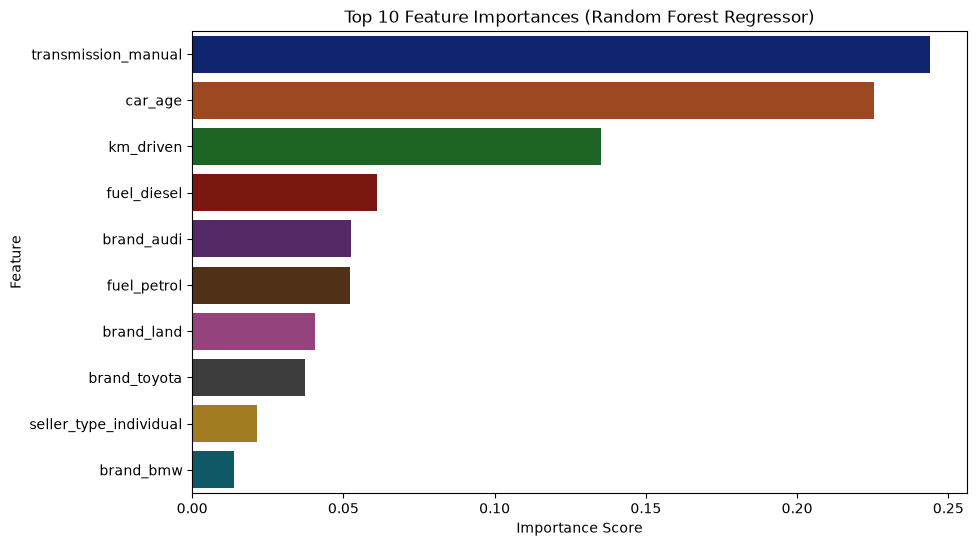

In [79]:
# Extracting the feature importances directly from the trained Random Forest model
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 10 most influential features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df.head(10), 
    hue='Feature', 
    palette='dark', 
    legend=False
)
plt.title('Top 10 Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [80]:
#here, the top 10 feature importances has been plotted by following the Random Forest Regressor, based on the features 

Upon inspecting the both model training plots, we may observe the following conclusive note:

Linear Regression relies almost entirely on car age, whereas Random Forest captures non-linear, usage based feature(km_driven) more effectively

# Conclusion:

The evaluation of the MAE, RMSE, and R^2 scores, for the two models-(Linear Regression,and Random Forest, we get these following observation:

The MAE, RMSE, and R^2 scores of the Linear Regression Model are maximum.

Project Summary & Key Insights
1) Model Evaluation: The Random Forest Regressor achieved the best overall performance with an R^2 score of approximately 0.585, outperforming Linear Regression and Gradient Boosting.
2) Key Feature Drivers:
  Transmission Type: Manual vs. Automatic transmission serves as the strongest predictor of selling price.
  Vehicle Age and Mileage: 'car_age' and 'km_driven' are major factors in price depreciation.
   Fuel Type and Brand: Vehicles running on 'fuel_diesel' and premium brands ('brand_audi', 'brand_land', 'brand_bmw') maintain higher resale values.